1.Importing the Dependencies

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

2.Data Cleaning

In [42]:
# Load the dataset (Assuming file is in the same directory)
df = pd.read_csv('creditcard.csv')

# Checking for missing values
print("Missing values count:\n", df.isnull().sum())
# The dataset usually has no missing values, but if any, we drop them
df.dropna(inplace=True)

Missing values count:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


3.Data Visualization

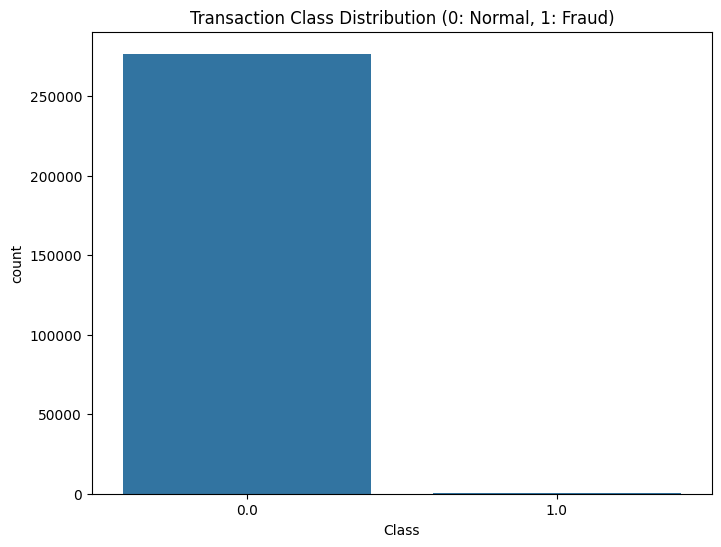

In [43]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Transaction Class Distribution (0: Normal, 1: Fraud)')
plt.show()

4.Exploratory Data Analysis (EDA)

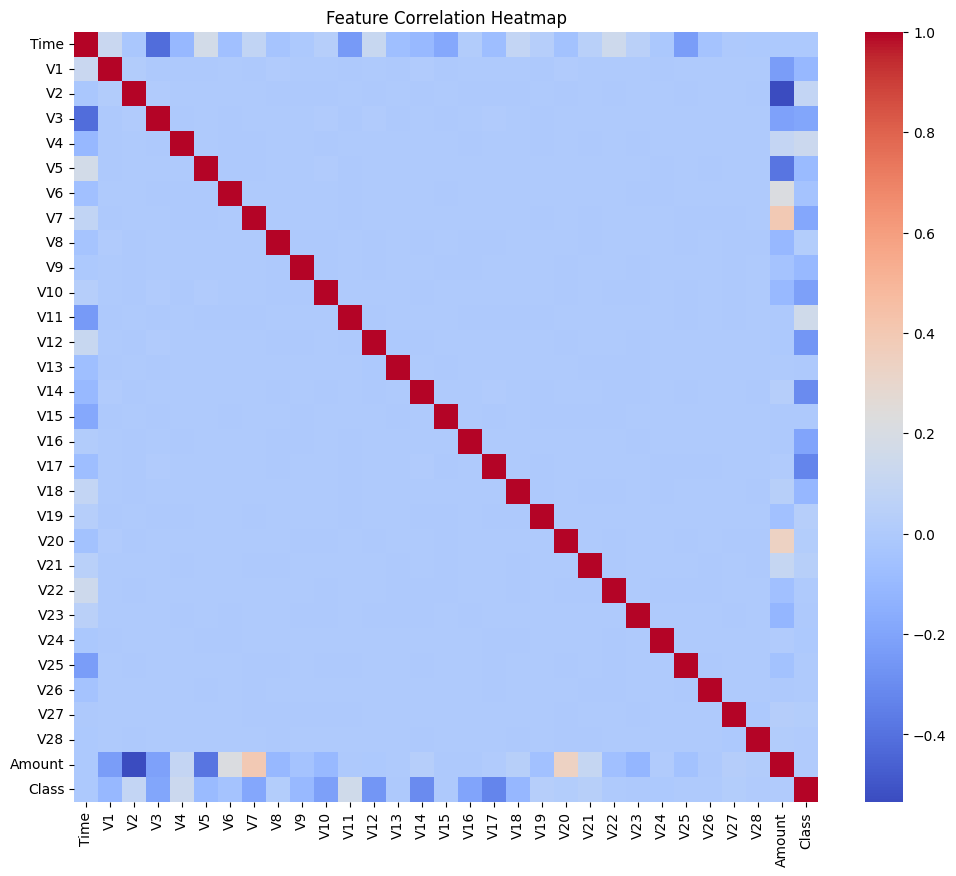

In [44]:
#Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

5.Data Modeling

In [45]:
# Identifying the structure of our model input.
# In this dataset:
# 'Class' is our dependent variable (Target) - 0 for Normal, 1 for Fraud.
# All other columns are independent variables (Features).

print("Original Dataset Shape:", df.shape)

Original Dataset Shape: (277214, 31)


6.Splitting the Data into Features and Targets

In [46]:
X = df.drop(columns=['Class'], axis=1)
y = df['Class']

7.Splitting the Data into Test and Training Data

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

8.Model Training

In [48]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

9.Model evaluation

In [49]:
y_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9989538805620186

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     55346
         1.0       0.68      0.77      0.72        97

    accuracy                           1.00     55443
   macro avg       0.84      0.89      0.86     55443
weighted avg       1.00      1.00      1.00     55443



10.Communication and Visualization (Confusion Matrix)

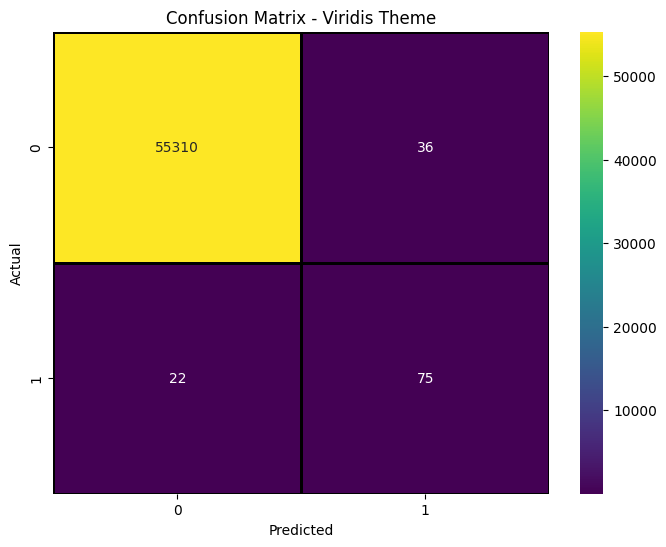

In [50]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', linewidths=2, linecolor='black')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Viridis Theme')
plt.show()

11.Model saving (as .sav file)

In [51]:
# Saving only the model as .sav
joblib.dump(model, 'credit_card_model.sav')
print("Model saved as credit_card_model.sav")

Model saved as credit_card_model.sav


12.Data automated pipeline implementation

In [52]:
# Creating a pipeline that includes scaling and the model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Training the pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

13.Pipeline saving (compressed)

In [53]:
# Saving the entire pipeline with compression (level 3)
joblib.dump(pipeline, 'full_pipeline.sav', compress=3)
print("Compressed Pipeline saved as full_pipeline.sav")

Compressed Pipeline saved as full_pipeline.sav
